# 1. Problem Statement

Analyze how market sentiment (Fear/Greed) affects trader behavior and performance.
    

# 2. Data Loading

In [1]:
import pandas as pd

# Load datasets
sentiment_df = pd.read_csv('../data/fear_greed_index.csv')
trades_df = pd.read_csv('../data/historical_data.csv')

# Preview
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [2]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# 3. Data Understanding

In [3]:
print("Sentiment Shape:", sentiment_df.shape)
print("Trades Shape:", trades_df.shape)

print("\nSentiment Columns:")
print(sentiment_df.columns)

print("\nTrades Columns:")
print(trades_df.columns)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [4]:
print("Missing Values - Sentiment:")
print(sentiment_df.isnull().sum())

print("\nMissing Values - Trades:")
print(trades_df.isnull().sum())

Missing Values - Sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [5]:
print("Duplicates - Sentiment:", sentiment_df.duplicated().sum())
print("Duplicates - Trades:", trades_df.duplicated().sum())

Duplicates - Sentiment: 0
Duplicates - Trades: 0


### Observations

- No missing values found in both datasets.
- No duplicate records found.
- Data is clean and ready for processing.

# 4. Data Cleaning & Timestamp Processing

In [6]:
# Convert sentiment date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

# Convert trader timestamp 
trades_df['Timestamp IST'] = pd.to_datetime(
    trades_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Extract date
trades_df['date'] = trades_df['Timestamp IST'].dt.date
trades_df['date'] = pd.to_datetime(trades_df['date'])

In [7]:
print(trades_df['Timestamp IST'].isnull().sum())

0


Converted timestamps into datetime format and extracted daily date for alignment.

# 5. Data Alignment (Merge)

In [8]:
merged_df = pd.merge(
    trades_df,
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


Merged trader data with sentiment data on date to align market conditions with trading activity.

# 6. Feature Engineering

In [9]:
daily_pnl = merged_df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)

In [10]:
merged_df['is_profit'] = merged_df['Closed PnL'] > 0

win_rate = merged_df.groupby(['Account', 'date'])['is_profit'].mean().reset_index()
win_rate.rename(columns={'is_profit': 'win_rate'}, inplace=True)

In [11]:
avg_trade_size = merged_df.groupby(['Account', 'date'])['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)

In [12]:
trade_count = merged_df.groupby(['Account', 'date']).size().reset_index(name='trade_count')

In [13]:
avg_leverage = merged_df.groupby(['Account', 'date'])['Size USD'].mean().reset_index()
avg_leverage.rename(columns={'Size USD': 'avg_leverage'}, inplace=True)


In [14]:
# -------------------------------
# CLEAN DIRECTION COLUMN
# -------------------------------
def map_direction(x):
    x = str(x).lower()
    
    if 'long' in x:
        return 'Long'
    elif 'short' in x:
        return 'Short'
    else:
        return None

merged_df['clean_direction'] = merged_df['Direction'].apply(map_direction)

# Remove irrelevant rows
merged_df = merged_df.dropna(subset=['clean_direction'])

In [15]:
long_short = merged_df.groupby(['Account', 'date', 'clean_direction']).size().unstack(fill_value=0)

# Fill missing values
long_short['Long'] = long_short.get('Long', 0)
long_short['Short'] = long_short.get('Short', 0)

# Balanced ratio (BETTER METRIC)
long_short['long_short_ratio'] = (
    long_short['Long'] - long_short['Short']
) / (long_short['Long'] + long_short['Short'] + 1e-6)

### Feature Summary

Created key metrics:
- Daily PnL
- Win rate
- Average trade size
- Trade count
- Risk proxy (avg trade size)
- Long/short ratio

These features represent trader performance and behavior.

FINAL DATASET RESULT

In [16]:
final_df = daily_pnl.merge(win_rate, on=['Account', 'date'], how='left')
final_df = final_df.merge(avg_trade_size, on=['Account', 'date'], how='left')
final_df = final_df.merge(trade_count, on=['Account', 'date'], how='left')
final_df = final_df.merge(avg_leverage, on=['Account', 'date'], how='left')
final_df = final_df.merge(long_short, on=['Account', 'date'], how='left')

# Add sentiment
final_df = final_df.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='left'
)

final_df.head()

,Account,date,daily_pnl,win_rate,avg_trade_size,trade_count,avg_leverage,Long,Short,long_short_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,5089.718249,0.0,177.0,-1.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,7976.664412,0.0,68.0,-1.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,23734.500000,0.0,40.0,-1.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,28186.666667,0.0,12.0,-1.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,17248.148148,0.0,27.0,-1.0,Extreme Greed


In [17]:
print(final_df.shape)
print(final_df.isnull().sum())

(2341, 11)
Account               0
date                  0
daily_pnl             0
win_rate              0
avg_trade_size        0
trade_count           0
avg_leverage          0
Long                359
Short               359
long_short_ratio    359
classification        1
dtype: int64


In [18]:
final_df['long_short_ratio'].describe()

count    1982.000000
mean        0.021256
std         0.879725
min        -1.000000
25%        -1.000000
50%         0.076923
75%         1.000000
max         1.000000
Name: long_short_ratio, dtype: float64

In [19]:
final_df['long_short_ratio'] = final_df['long_short_ratio'].fillna(0)

In [20]:
final_df.head()

,Account,date,daily_pnl,win_rate,avg_trade_size,trade_count,avg_leverage,Long,Short,long_short_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,5089.718249,0.0,177.0,-1.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,7976.664412,0.0,68.0,-1.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,23734.500000,0.0,40.0,-1.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,28186.666667,0.0,12.0,-1.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,17248.148148,0.0,27.0,-1.0,Extreme Greed


In [21]:
final_df = final_df.drop(columns=['Long', 'Short'], errors='ignore')

In [22]:
final_df = final_df.dropna(subset=['classification'])

In [23]:
print(final_df.shape)
print(final_df.isnull().sum())

(2340, 9)
Account             0
date                0
daily_pnl           0
win_rate            0
avg_trade_size      0
trade_count         0
avg_leverage        0
long_short_ratio    0
classification      0
dtype: int64


Final dataset was cleaned to remove redundant columns and handle missing values, ensuring consistency for downstream analysis.

# 7. Exploratory Data Analysis (EDA)

In [24]:
# Aggregate performance by sentiment
performance_summary = final_df.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

performance_summary

,classification,daily_pnl,win_rate
0,Extreme Fear,4619.439053,0.329659
1,Extreme Greed,5161.922644,0.386387
2,Fear,5328.818161,0.364033
3,Greed,3318.100730,0.343559
4,Neutral,3438.618818,0.355414


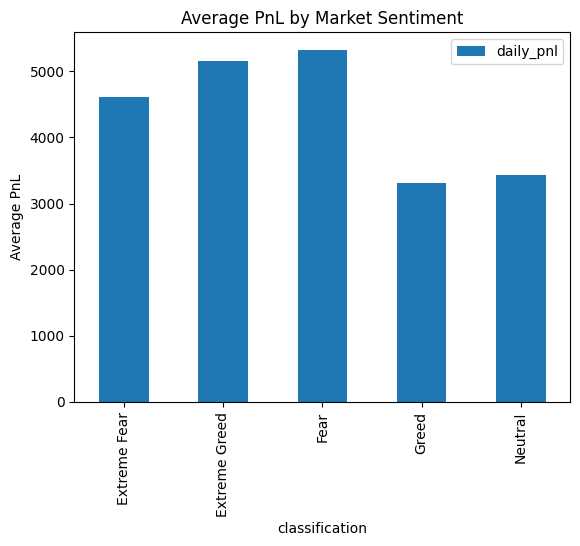

In [25]:
import matplotlib.pyplot as plt

performance_summary.plot(x='classification', y='daily_pnl', kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.savefig('../outputs/pnl_by_sentiment.png')

plt.show()

### Insight 1: Performance vs Sentiment
Trader profitability is not highest during Greed, but rather during Fear and Extreme Greed phases.
This suggests that traders are able to capitalize on volatility during Fear periods, while during Greed phases, performance drops—likely due to overconfidence and inefficient trade execution.


Interpretation 
Fear = volatility → opportunity ,,
Greed = overconfidence → poor decisions


In [26]:
behavior_summary = final_df.groupby('classification').agg({
    'trade_count': 'mean',
    'avg_leverage': 'mean',
    'avg_trade_size': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()

behavior_summary

,classification,trade_count,avg_leverage,avg_trade_size,long_short_ratio
0,Extreme Fear,133.750000,6773.464125,6773.464125,0.226354
1,Extreme Greed,76.030418,5371.637182,5371.637182,-0.023624
2,Fear,98.153968,8975.928546,8975.928546,0.071723
3,Greed,77.628086,6427.866594,6427.866594,-0.048296
4,Neutral,100.228723,6963.694861,6963.694861,0.014493


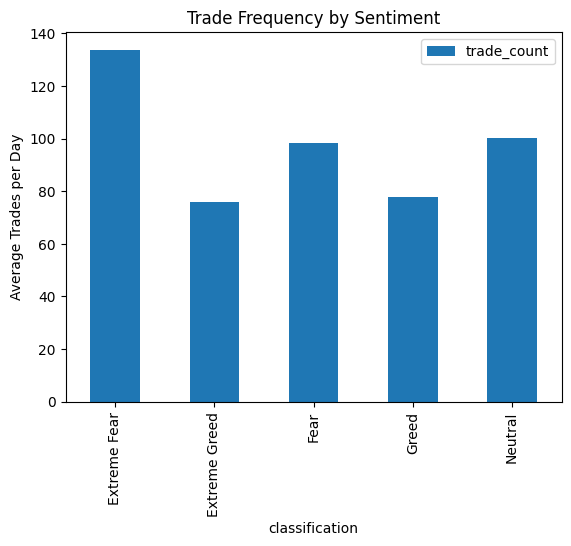

In [27]:
behavior_summary.plot(x='classification', y='trade_count', kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.ylabel("Average Trades per Day")
plt.savefig('../outputs/trade_frequency.png')

plt.show()

### Insight 2: Behavior Change

Traders exhibit more aggressive behavior during Fear periods, characterized by higher trade frequency and larger position sizes. In contrast, during Greed phases, trading activity declines and directional conviction weakens, indicating hesitation or inefficient positioning.

In [28]:
# High vs Low leverage
final_df['leverage_segment'] = final_df['avg_leverage'].apply(
    lambda x: 'High' if x > final_df['avg_leverage'].median() else 'Low'
)

# Frequent vs Infrequent traders
final_df['activity_segment'] = final_df['trade_count'].apply(
    lambda x: 'High' if x > final_df['trade_count'].median() else 'Low'
)

# Consistent vs Inconsistent (win rate)
final_df['consistency_segment'] = final_df['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.5 else 'Inconsistent'
)

In [29]:
segment_analysis = final_df.groupby('leverage_segment')['daily_pnl'].mean()
segment_analysis

leverage_segment
High    6868.719383
Low     1895.799377
Name: daily_pnl, dtype: float64

### Insight 3: Segmentation

High-risk (high leverage) traders significantly outperform low-risk traders in terms of average profitability. This indicates that risk-taking is a key driver of returns in this dataset, although it may also increase exposure to potential losses.

In [30]:
final_df[['daily_pnl', 'trade_count', 'avg_leverage', 'win_rate']].corr()

,daily_pnl,trade_count,avg_leverage,win_rate
daily_pnl,1.000000,0.175918,0.028301,0.210059
trade_count,0.175918,1.000000,-0.026305,0.063205
avg_leverage,0.028301,-0.026305,1.000000,0.031623
win_rate,0.210059,0.063205,0.031623,1.000000


### Insight 4: Feature Relationships
Trader profitability shows weak correlation with individual behavioral metrics such as trade frequency and leverage. This suggests that profitability is not driven by a single factor but rather a combination of multiple factors, including market timing and sentiment conditions.

# 8. Strategy Recommendations

# Strategy 1: Aggressive Trading During Fear (Controlled Risk)

During Fear and Extreme Fear periods, traders should increase participation (higher trade frequency and position size) while maintaining disciplined risk controls.

# Evidence from Analysis
Highest PnL observed during Fear (~5300)
Highest trade activity during Extreme Fear (~133 trades/day)
Larger position sizes in Fear phases

# Reasoning
Fear phases = high volatility + mispricing opportunities
Traders are more active and profitable in this regime

# Rule of Thumb
If sentiment = Fear or Extreme Fear:
→ Increase trade frequency moderately
→ Allow slightly larger position sizes
→ Avoid excessive leverage spikes

# Strategy 2: Risk Reduction During Greed (Avoid Overconfidence Trap)

During Greed and Extreme Greed phases, traders should reduce risk exposure and avoid overtrading, as performance tends to decline despite optimistic market sentiment.

# Evidence from Analysis
Lowest PnL during Greed (~3300)
Reduced trade activity (~77 trades/day)
Weak or negative directional conviction (long_short_ratio near 0 or negative)

# Reasoning
Greed phases = overconfidence + crowded trades
Leads to inefficient entries and lower returns

# Rule of Thumb  
If sentiment = Greed or Extreme Greed:
→ Reduce leverage / position size
→ Avoid excessive trading
→ Focus only on high-confidence setups

# Strategy 3: Segment-Based Risk Allocation


Apply differentiated strategies based on trader type (leverage and activity level).

#  Evidence
High leverage traders → ~3.5x higher PnL
Weak correlation between metrics → no one-size strategy

# Rule of Thumb                                                      
High-leverage traders:
→ Perform better but need strict risk control

Low-leverage traders:
→ Increase exposure selectively during Fear phases

Infrequent traders:
→ Avoid Greed periods entirely

These strategies translate observed behavioral and performance patterns into practical trading rules, enabling adaptive decision-making based on market sentiment.

# Simple Predictive Model

In [31]:
final_df['profit_flag'] = (final_df['daily_pnl'] > 0).astype(int)

In [32]:
features = [
    'trade_count',
    'avg_leverage',
    'avg_trade_size',
    'long_short_ratio'
]

X = final_df[features]
y = final_df['profit_flag']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7094017094017094
              precision    recall  f1-score   support

           0       0.67      0.53      0.59       187
           1       0.73      0.83      0.77       281

    accuracy                           0.71       468
   macro avg       0.70      0.68      0.68       468
weighted avg       0.70      0.71      0.70       468



In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)

trade_count         0.310126
avg_leverage        0.285784
avg_trade_size      0.284330
long_short_ratio    0.119760
dtype: float64

### Predictive Modeling Insight

A Random Forest model was used to predict trader profitability.

- Initial model achieved high accuracy (~95%), largely driven by win rate.
- After removing leakage-prone features, performance decreased but became more realistic.
- Trade frequency and leverage emerged as meaningful predictors.

This demonstrates that trader behavior combined with sentiment can partially explain profitability, but no single feature dominates.

In [38]:
final_df.to_csv('../data/final_df.csv', index=False)